# Hybrid Brain Tumor Detection from MRI

## Computer Vision + Classical Machine Learning + Deep Learning

This notebook implements a **binary MRI brain-tumor detector**:

\[ \text{MRI image} \rightarrow \text{tumor present / no tumor} \]

It intentionally combines three complementary approaches:

1. **Computer vision preprocessing**
   - grayscale normalization
   - CLAHE contrast enhancement
   - mild denoising
   - foreground/brain-region cropping
2. **Classical machine learning**
   - HOG texture/shape features
   - Local Binary Pattern (LBP) texture features
   - intensity statistics
   - Support Vector Machine (SVM)
3. **Deep learning**
   - transfer learning with EfficientNetB0
   - fine-tuning on MRI images
   - extraction of learned deep image embeddings
4. **Hybrid model**
   - concatenates handcrafted CV features with deep embeddings
   - trains a calibrated SVM on the fused representation

> **Important:** A high validation/test accuracy is not guaranteed. Performance
> depends on dataset size, labels, acquisition variability, preprocessing,
> and—most importantly—avoiding data leakage. If several MRI slices come from
> the same patient, split **by patient**, not by image.


## Expected dataset structure

The simplest supported layout is:

```text
dataset/
├── no_tumor/
│   ├── image001.jpg
│   ├── image002.jpg
│   └── ...
└── tumor/
    ├── image101.jpg
    ├── image102.jpg
    └── ...
```

Supported image types include PNG, JPG/JPEG, BMP, TIF/TIFF.

If your dataset uses different class-folder names, edit `NEGATIVE_CLASS` and
`POSITIVE_CLASS` below.


In [13]:

# If necessary, install dependencies once:
# !pip install numpy pandas matplotlib scikit-learn scikit-image opencv-python tensorflow joblib

from pathlib import Path
import os, random, json, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from skimage.feature import hog, local_binary_pattern

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, precision_recall_curve, auc
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight

import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPU devices: []


## 1. Configuration


In [14]:

# ===== EDIT THIS PATH =====
DATASET_DIR = Path(r"..\Datasets\Brain Tumor 12K Mri Images\Images_\Images_")

NEGATIVE_CLASS = "Normal"
POSITIVE_CLASS = "Embryonic Tumors"

IMG_SIZE = 224
BATCH_SIZE = 24
EPOCHS_HEAD = 8
EPOCHS_FINE = 8

TEST_SIZE = 0.15
VAL_SIZE = 0.15  # fraction of entire dataset

# Turn this on only after the basic pipeline works.
RUN_SVM_HYPERPARAMETER_SEARCH = False

MODEL_DIR = Path("brain_tumor_models")
MODEL_DIR.mkdir(exist_ok=True)


## 2. Discover and audit the MRI dataset


In [15]:

SUPPORTED_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def build_dataframe(dataset_dir):
    rows = []
    mapping = {NEGATIVE_CLASS: 0, POSITIVE_CLASS: 1}
    for class_name, label in mapping.items():
        folder = dataset_dir / class_name
        if not folder.exists():
            raise FileNotFoundError(f"Missing class folder: {folder.resolve()}")
        for p in folder.rglob("*"):
            if p.suffix.lower() in SUPPORTED_EXTENSIONS:
                rows.append({"path": str(p), "label": label, "class_name": class_name})
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("No supported MRI images were found.")
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df = build_dataframe(DATASET_DIR)
display(df.head())
print("\nClass counts:")
display(df["class_name"].value_counts())
print(f"Total images: {len(df):,}")


,path,label,class_name
0,..\Datasets\Brain Tumor 12K Mri Images\Images_...,1,Embryonic Tumors
1,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,Normal
2,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,Normal
3,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,Normal
4,..\Datasets\Brain Tumor 12K Mri Images\Images_...,0,Normal



Class counts:


class_name
Normal              3591
Embryonic Tumors    2640
Name: count, dtype: int64

Total images: 6,231


### Leakage warning

MRI datasets often contain **many slices from the same patient**. A random
image-level split can place slices from one patient into both training and test
sets, producing deceptively high accuracy.

If patient identifiers are available, replace the simple split below with
`GroupShuffleSplit` or another patient-level grouping strategy.


In [16]:

# Stratified image-level split.
# Replace with patient-level/grouped splitting whenever patient IDs are available.

train_df, temp_df = train_test_split(
    df, test_size=(VAL_SIZE + TEST_SIZE),
    stratify=df["label"], random_state=SEED
)

relative_test = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

val_df, test_df = train_test_split(
    temp_df, test_size=relative_test,
    stratify=temp_df["label"], random_state=SEED
)

print("Train:", len(train_df), train_df["label"].value_counts().to_dict())
print("Val:  ", len(val_df), val_df["label"].value_counts().to_dict())
print("Test: ", len(test_df), test_df["label"].value_counts().to_dict())


Train: 4361 {0: 2513, 1: 1848}
Val:   935 {0: 539, 1: 396}
Test:  935 {0: 539, 1: 396}


## 3. Computer-vision preprocessing


In [17]:

def load_grayscale(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return img

def crop_foreground(img, threshold=8):
    # Removes large uniform black borders that are common in MRI exports.
    mask = img > threshold
    coords = np.argwhere(mask)
    if coords.size == 0:
        return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    cropped = img[y0:y1, x0:x1]
    return cropped if cropped.size else img

def preprocess_cv(path, size=IMG_SIZE):
    img = load_grayscale(path)
    img = crop_foreground(img)

    # Mild denoising
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    # Resize after cropping
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    return img


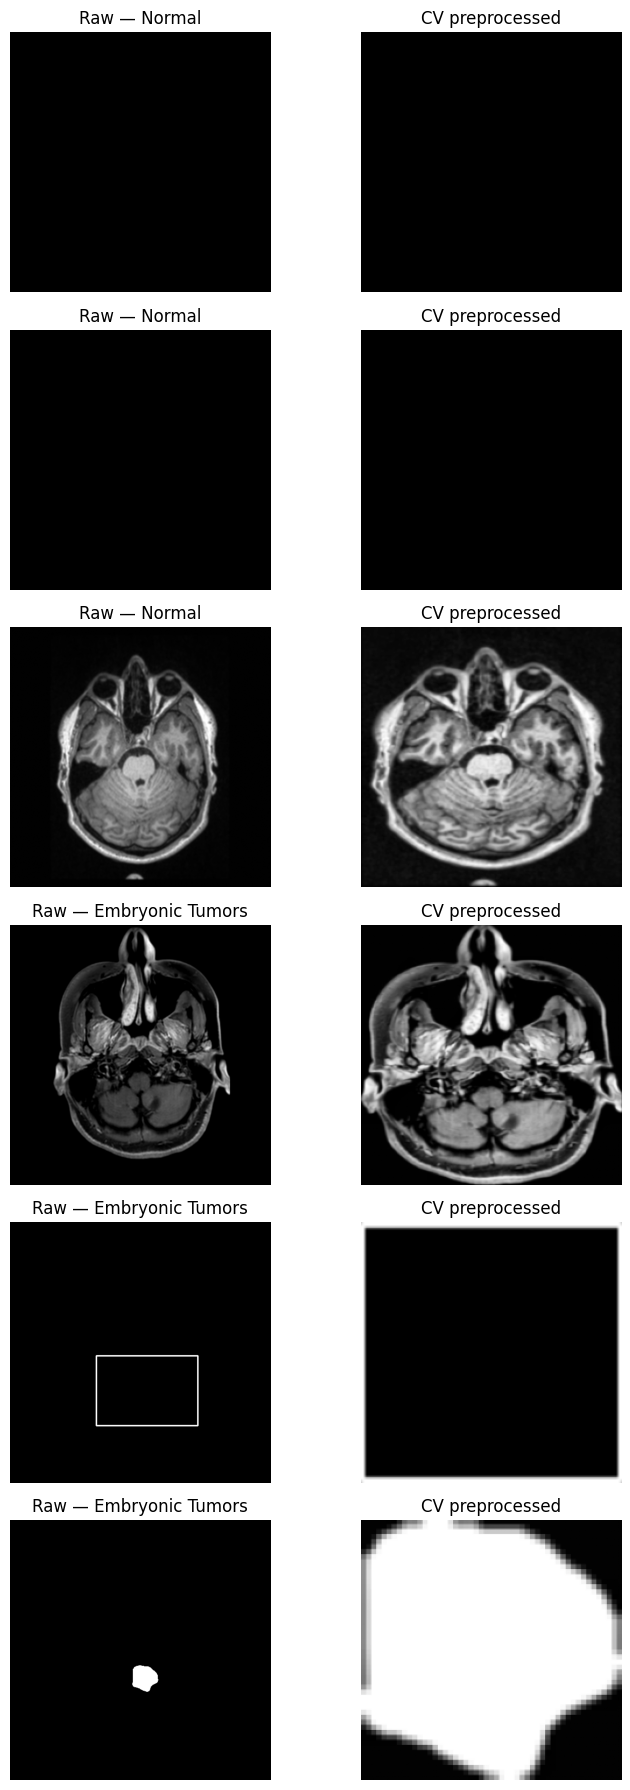

In [18]:

# Visualize raw vs. preprocessed examples
sample = df.groupby("label", group_keys=False).sample(min(3, df["label"].value_counts().min()), random_state=SEED)

fig, axes = plt.subplots(len(sample), 2, figsize=(8, 3 * len(sample)))
if len(sample) == 1:
    axes = np.array([axes])

for row_i, (_, row) in enumerate(sample.iterrows()):
    raw = load_grayscale(row["path"])
    proc = preprocess_cv(row["path"])

    axes[row_i, 0].imshow(raw, cmap="gray")
    axes[row_i, 0].set_title(f"Raw — {row['class_name']}")
    axes[row_i, 0].axis("off")

    axes[row_i, 1].imshow(proc, cmap="gray")
    axes[row_i, 1].set_title("CV preprocessed")
    axes[row_i, 1].axis("off")

plt.tight_layout()
plt.show()


## 4. Handcrafted computer-vision features


In [19]:

LBP_POINTS = 24
LBP_RADIUS = 3

def extract_handcrafted_features(path):
    img = preprocess_cv(path)

    # HOG: local gradients, edges, shape
    hog_vec = hog(
        img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )

    # LBP: local texture
    img_u8 = (img * 255).astype(np.uint8)
    lbp = local_binary_pattern(img_u8, LBP_POINTS, LBP_RADIUS, method="uniform")
    n_bins = LBP_POINTS + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(n_bins + 1), density=True)

    # Intensity distribution statistics
    stats = np.array([
        img.mean(),
        img.std(),
        np.percentile(img, 10),
        np.percentile(img, 25),
        np.percentile(img, 50),
        np.percentile(img, 75),
        np.percentile(img, 90),
    ], dtype=np.float32)

    return np.concatenate([hog_vec, lbp_hist, stats]).astype(np.float32)

def build_handcrafted_matrix(frame):
    X = np.vstack([extract_handcrafted_features(p) for p in frame["path"]])
    y = frame["label"].to_numpy()
    return X, y

Xh_train, y_train = build_handcrafted_matrix(train_df)
Xh_val, y_val = build_handcrafted_matrix(val_df)
Xh_test, y_test = build_handcrafted_matrix(test_df)

print("Handcrafted feature dimension:", Xh_train.shape[1])


Handcrafted feature dimension: 6117


## 5. Classical ML baseline: HOG + LBP + intensity + SVM


In [20]:

svm_baseline = Pipeline([
    ("scale", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=5.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=SEED
    ))
])

svm_baseline.fit(Xh_train, y_train)

val_prob = svm_baseline.predict_proba(Xh_val)[:, 1]
val_pred = (val_prob >= 0.5).astype(int)

print("Validation classification report")
print(classification_report(y_val, val_pred, target_names=[NEGATIVE_CLASS, POSITIVE_CLASS]))


Validation classification report
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00       539
Embryonic Tumors       1.00      1.00      1.00       396

        accuracy                           1.00       935
       macro avg       1.00      1.00      1.00       935
    weighted avg       1.00      1.00      1.00       935



## 6. Deep learning: EfficientNetB0 transfer learning


In [21]:

AUTOTUNE = tf.data.AUTOTUNE

def tf_load_preprocessed(path, label):
    def _py_load(p):
        p = p.numpy().decode("utf-8")
        x = preprocess_cv(p)
        x = np.stack([x, x, x], axis=-1)  # grayscale -> pseudo-RGB
        return x.astype(np.float32)

    x = tf.py_function(_py_load, [path], Tout=tf.float32)
    x.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return x, tf.cast(label, tf.float32)

def make_dataset(frame, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (frame["path"].astype(str).values, frame["label"].values)
    )
    if training:
        ds = ds.shuffle(len(frame), seed=SEED)
    ds = ds.map(tf_load_preprocessed, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.04, 0.04),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
# EfficientNet in tf.keras includes its own rescaling.
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="deep_embedding")(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

dl_model = keras.Model(inputs, outputs, name="brain_tumor_efficientnet")

dl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)
class_weights = {0: float(class_weights_arr[0]), 1: float(class_weights_arr[1])}
print("Class weights:", class_weights)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_DIR / "efficientnet_best.keras",
        monitor="val_auc", mode="max", save_best_only=True
    )
]

history_head = dl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weights,
    callbacks=callbacks
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Class weights: {0: 0.8676880222841226, 1: 1.1799242424242424}
Epoch 1/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 64s 319ms/step - accuracy: 0.5013 - auc: 0.4969 - loss: 0.7015 - precision: 0.4248 - recall: 0.5000 - val_accuracy: 0.4235 - val_auc: 0.6950 - val_loss: 0.7121 - val_precision: 0.4235 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 76s 420ms/step - accuracy: 0.5058 - auc: 0.5041 - loss: 0.7003 - precision: 0.4275 - recall: 0.4897 - val_accuracy: 0.5765 - val_auc: 0.5000 - val_loss: 0.6855 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 50s 274ms/step - accuracy: 0.5001 - auc: 0.5005 - loss: 0.6993 - precision: 0.4249 - recall: 0.5081 - val_accuracy: 0.5765 - val_auc: 0.7593 - val_loss: 0.6878 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 43s 238ms/step - accuracy: 0

## 7. Fine-tune the upper EfficientNet layers


In [22]:

base_model.trainable = True

# Freeze most of the backbone and fine-tune only the upper portion.
fine_tune_from = int(len(base_model.layers) * 0.75)
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# BatchNorm layers are commonly kept frozen during fine-tuning on small datasets.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

dl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

history_fine = dl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 59s 283ms/step - accuracy: 0.5095 - auc: 0.5102 - loss: 0.6957 - precision: 0.4331 - recall: 0.5097 - val_accuracy: 0.8000 - val_auc: 0.8041 - val_loss: 0.6905 - val_precision: 0.8012 - val_recall: 0.7020 - learning_rate: 1.0000e-05
Epoch 2/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 51s 281ms/step - accuracy: 0.5061 - auc: 0.5191 - loss: 0.6947 - precision: 0.4372 - recall: 0.5768 - val_accuracy: 0.8043 - val_auc: 0.5150 - val_loss: 0.6906 - val_precision: 0.8087 - val_recall: 0.7045 - learning_rate: 1.0000e-05
Epoch 3/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 50s 273ms/step - accuracy: 0.5026 - auc: 0.5189 - loss: 0.6930 - precision: 0.4348 - recall: 0.5795 - val_accuracy: 0.6374 - val_auc: 0.6151 - val_loss: 0.6892 - val_precision: 0.9831 - val_recall: 0.1465 - learning_rate: 1.0000e-05
Epoch 4/8
182/182 ━━━━━━━━━━━━━━━━━━━━ 95s 521ms/step - accuracy: 0.5054 - auc: 0.5228 - loss: 0.6928 - precision: 0.4365 - recall: 0.5747 - val_accuracy: 0.5765 - val_auc: 0.7334 - va

## 8. Plot deep-learning training history


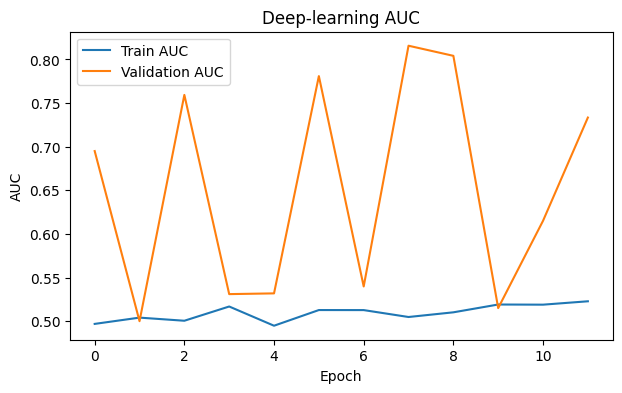

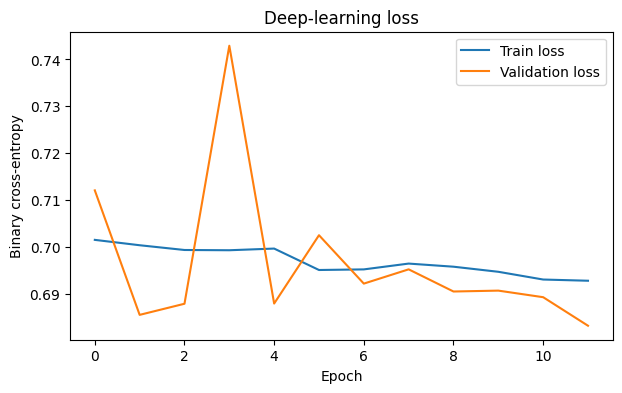

In [23]:

def merge_history(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

train_auc = merge_history(history_head, history_fine, "auc")
val_auc = merge_history(history_head, history_fine, "val_auc")
train_loss = merge_history(history_head, history_fine, "loss")
val_loss = merge_history(history_head, history_fine, "val_loss")

plt.figure(figsize=(7, 4))
plt.plot(train_auc, label="Train AUC")
plt.plot(val_auc, label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Deep-learning AUC")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(train_loss, label="Train loss")
plt.plot(val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Deep-learning loss")
plt.legend()
plt.show()


## 9. Extract deep embeddings


In [24]:

embedding_model = keras.Model(
    inputs=dl_model.input,
    outputs=dl_model.get_layer("deep_embedding").output
)

def embeddings_from_dataset(ds):
    return embedding_model.predict(ds, verbose=1)

Xd_train = embeddings_from_dataset(make_dataset(train_df))
Xd_val = embeddings_from_dataset(make_dataset(val_df))
Xd_test = embeddings_from_dataset(make_dataset(test_df))

print("Deep embedding dimension:", Xd_train.shape[1])


182/182 ━━━━━━━━━━━━━━━━━━━━ 35s 185ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step
Deep embedding dimension: 1280


## 10. Hybrid feature fusion

This is the core hybrid stage:

\[ ext{Hybrid feature vector} = [ ext{HOG} \;|\; ext{LBP} \;|\; ext{intensity
statistics} \;|\; ext{EfficientNet embedding}] \]

A calibrated SVM then learns the final tumor/no-tumor decision boundary.


In [25]:

Xhy_train = np.hstack([Xh_train, Xd_train]).astype(np.float32)
Xhy_val = np.hstack([Xh_val, Xd_val]).astype(np.float32)
Xhy_test = np.hstack([Xh_test, Xd_test]).astype(np.float32)

print("Hybrid feature dimension:", Xhy_train.shape[1])

base_svm = SVC(
    kernel="rbf",
    C=3.0,
    gamma="scale",
    class_weight="balanced",
    probability=False,
    random_state=SEED
)

# Probability calibration gives a usable probability-like output.
hybrid_model = Pipeline([
    ("scale", StandardScaler()),
    ("clf", CalibratedClassifierCV(base_svm, method="sigmoid", cv=3))
])

hybrid_model.fit(Xhy_train, y_train)

val_prob_hybrid = hybrid_model.predict_proba(Xhy_val)[:, 1]


Hybrid feature dimension: 7397


## 11. Select the decision threshold using validation data


In [26]:

def find_best_threshold(y_true, probs):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = []
    for t in thresholds:
        pred = (probs >= t).astype(int)
        scores.append(f1_score(y_true, pred))
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

best_threshold, best_val_f1 = find_best_threshold(y_val, val_prob_hybrid)
print("Selected threshold:", round(best_threshold, 3))
print("Validation F1:", round(best_val_f1, 4))


Selected threshold: 0.44
Validation F1: 0.9987


## 12. Final evaluation on the untouched test set


Handcrafted CV + SVM


,score
accuracy,0.996791
balanced_accuracy,0.996882
precision,0.994962
recall_sensitivity,0.997475
specificity,0.996289
f1,0.996217
roc_auc,0.999991


                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00       539
Embryonic Tumors       0.99      1.00      1.00       396

        accuracy                           1.00       935
       macro avg       1.00      1.00      1.00       935
    weighted avg       1.00      1.00      1.00       935



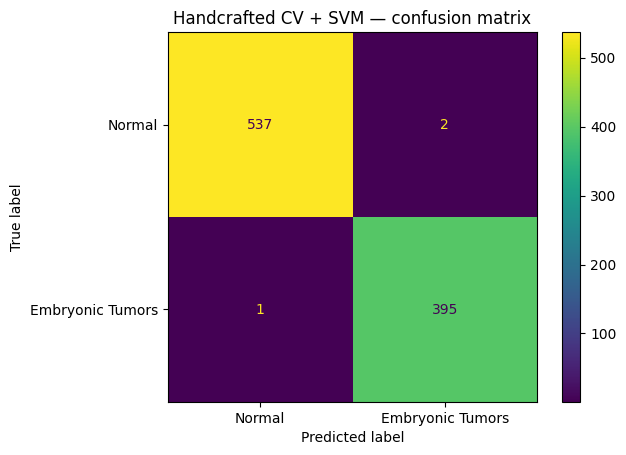

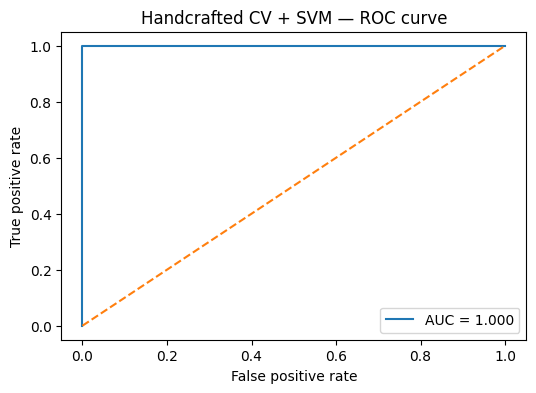

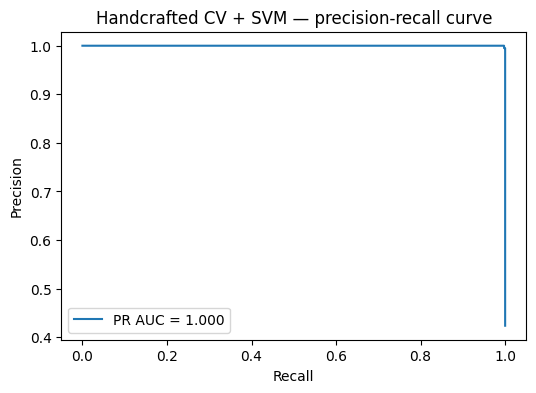

EfficientNetB0


,score
accuracy,0.787166
balanced_accuracy,0.774531
precision,0.780627
recall_sensitivity,0.691919
specificity,0.857143
f1,0.733601
roc_auc,0.864822


                  precision    recall  f1-score   support

          Normal       0.79      0.86      0.82       539
Embryonic Tumors       0.78      0.69      0.73       396

        accuracy                           0.79       935
       macro avg       0.79      0.77      0.78       935
    weighted avg       0.79      0.79      0.79       935



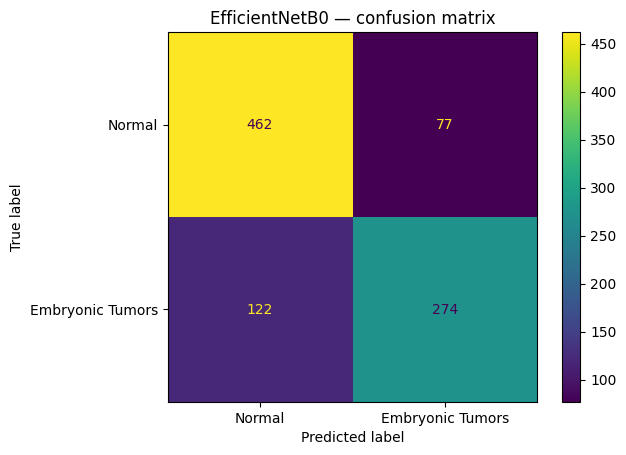

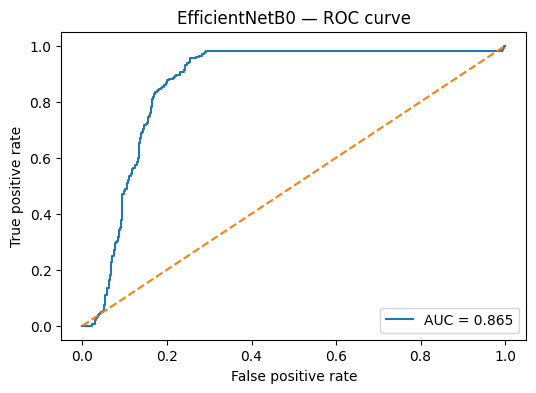

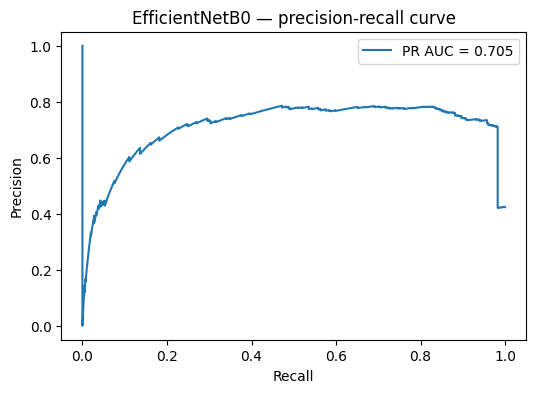

Hybrid CV + DL embeddings + SVM


,score
accuracy,0.998930
balanced_accuracy,0.999072
precision,0.997481
recall_sensitivity,1.000000
specificity,0.998145
f1,0.998739
roc_auc,1.000000


                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00       539
Embryonic Tumors       1.00      1.00      1.00       396

        accuracy                           1.00       935
       macro avg       1.00      1.00      1.00       935
    weighted avg       1.00      1.00      1.00       935



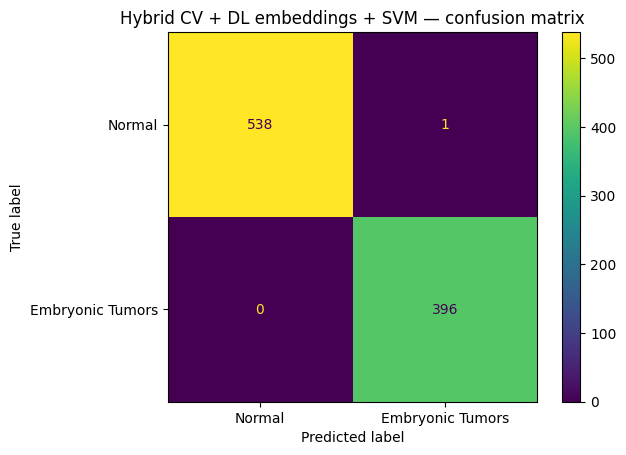

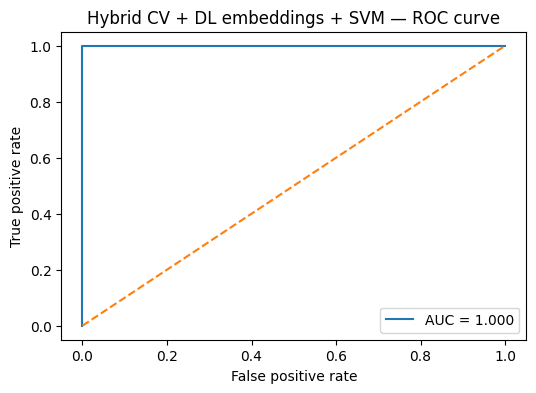

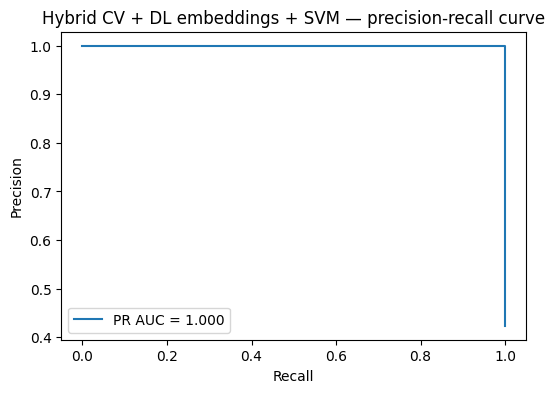

In [27]:

def evaluate_binary(y_true, probs, threshold=0.5, title="Model"):
    pred = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, pred, zero_division=0),
        "specificity": recall_score(y_true, pred, pos_label=0, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs)
    }

    print(title)
    display(pd.DataFrame([metrics]).T.rename(columns={0: "score"}))
    print(classification_report(y_true, pred, target_names=[NEGATIVE_CLASS, POSITIVE_CLASS]))

    ConfusionMatrixDisplay.from_predictions(
        y_true, pred,
        display_labels=[NEGATIVE_CLASS, POSITIVE_CLASS],
        values_format="d"
    )
    plt.title(f"{title} — confusion matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, probs)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"{title} — ROC curve")
    plt.legend()
    plt.show()

    precision, recall, _ = precision_recall_curve(y_true, probs)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} — precision-recall curve")
    plt.legend()
    plt.show()

    return metrics

# Classical CV/ML baseline
test_prob_svm = svm_baseline.predict_proba(Xh_test)[:, 1]
metrics_svm = evaluate_binary(y_test, test_prob_svm, 0.5, "Handcrafted CV + SVM")

# Deep model
test_prob_dl = dl_model.predict(test_ds, verbose=0).ravel()
metrics_dl = evaluate_binary(y_test, test_prob_dl, 0.5, "EfficientNetB0")

# Hybrid model
test_prob_hybrid = hybrid_model.predict_proba(Xhy_test)[:, 1]
metrics_hybrid = evaluate_binary(
    y_test, test_prob_hybrid, best_threshold, "Hybrid CV + DL embeddings + SVM"
)


In [28]:

comparison = pd.DataFrame({
    "CV + SVM": metrics_svm,
    "EfficientNetB0": metrics_dl,
    "Hybrid": metrics_hybrid
}).T

display(comparison.sort_values("roc_auc", ascending=False))


,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,roc_auc
Hybrid,0.998930,0.999072,0.997481,1.000000,0.998145,0.998739,1.000000
CV + SVM,0.996791,0.996882,0.994962,0.997475,0.996289,0.996217,0.999991
EfficientNetB0,0.787166,0.774531,0.780627,0.691919,0.857143,0.733601,0.864822


## 13. Grad-CAM visualization for model interpretability

Grad-CAM does **not** prove that the model is clinically correct, but it can
help inspect whether the deep network is focusing on plausible image regions
rather than borders, text markers, or scanner artifacts.


In [29]:

def find_last_conv_layer(model):
    # Search the full model recursively for the last 4D convolutional output.
    candidate = None
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            for sub in layer.layers:
                try:
                    if len(sub.output.shape) == 4:
                        candidate = sub.name
                except Exception:
                    pass
    return candidate

LAST_CONV_LAYER = find_last_conv_layer(dl_model)
print("Candidate last convolution layer:", LAST_CONV_LAYER)


Candidate last convolution layer: top_activation


In [30]:

def make_gradcam_heatmap(img_array, model, conv_base, last_conv_layer_name):
    # EfficientNet is nested inside dl_model.
    conv_model = keras.Model(
        conv_base.inputs,
        [conv_base.get_layer(last_conv_layer_name).output, conv_base.output]
    )

    # Build a model from full input -> nested base input features is cumbersome
    # because augmentation precedes the base. We therefore use the preprocessed
    # image directly through the base and the classifier head separately.
    classifier_input = keras.Input(shape=conv_base.output.shape[1:])
    x = classifier_input
    # reproduce post-base layers
    for layer in model.layers:
        if layer.name == "deep_embedding" or isinstance(layer, (layers.Dropout, layers.Dense)):
            x = layer(x)
    classifier_model = keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs, base_outputs = conv_model(img_array)
        tape.watch(conv_outputs)
        preds = classifier_model(base_outputs)
        score = preds[:, 0]

    grads = tape.gradient(score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.reduce_sum(conv_outputs[0] * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

def show_gradcam(path):
    img = preprocess_cv(path)
    rgb = np.stack([img, img, img], axis=-1)
    arr = np.expand_dims(rgb, 0).astype(np.float32)

    heat = make_gradcam_heatmap(arr, dl_model, base_model, LAST_CONV_LAYER)
    heat = cv2.resize(heat, (IMG_SIZE, IMG_SIZE))

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Preprocessed MRI")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img, cmap="gray")
    plt.imshow(heat, alpha=0.45, cmap="jet")
    plt.title("Grad-CAM attention")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Example:
# show_gradcam(test_df.iloc[0]["path"])


## 14. Save the trained models and metadata


In [31]:

dl_model.save(MODEL_DIR / "brain_tumor_efficientnet.keras")
joblib.dump(svm_baseline, MODEL_DIR / "handcrafted_svm.joblib")
joblib.dump(hybrid_model, MODEL_DIR / "hybrid_svm.joblib")

metadata = {
    "negative_class": NEGATIVE_CLASS,
    "positive_class": POSITIVE_CLASS,
    "image_size": IMG_SIZE,
    "hybrid_threshold": best_threshold,
    "handcrafted_dim": int(Xh_train.shape[1]),
    "deep_embedding_dim": int(Xd_train.shape[1]),
    "hybrid_dim": int(Xhy_train.shape[1])
}
with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to:", MODEL_DIR.resolve())


Saved to: C:\Users\sinco\Documents\GitHub\Medical-Imaging-Research\Code\brain_tumor_models


## 15. Inference on one new MRI


In [32]:

def predict_mri(path, threshold=best_threshold):
    path = str(path)

    # Handcrafted features
    handcrafted = extract_handcrafted_features(path)[None, :]

    # Deep input and embedding
    img = preprocess_cv(path)
    rgb = np.stack([img, img, img], axis=-1)[None, ...].astype(np.float32)
    deep_embedding = embedding_model.predict(rgb, verbose=0)

    # Hybrid probability
    hybrid_features = np.hstack([handcrafted, deep_embedding]).astype(np.float32)
    probability = float(hybrid_model.predict_proba(hybrid_features)[0, 1])
    predicted_label = int(probability >= threshold)

    result = {
        "prediction": POSITIVE_CLASS if predicted_label == 1 else NEGATIVE_CLASS,
        "tumor_probability": probability,
        "threshold": float(threshold)
    }
    return result

# Example:
# result = predict_mri("example_mri.jpg")
# print(result)


# Recommended validation before claiming "high accuracy"

For a research-quality result, strengthen the notebook with:

- **patient-level train/validation/test splitting**
- an **external test dataset** from a different institution/scanner
- repeated cross-validation or nested cross-validation
- confidence intervals for sensitivity, specificity, AUC, and Dice if
  segmentation is added
- duplicate-image detection
- checks for burned-in text, borders, labels, or scanner artifacts that could
  leak the class
- subgroup analysis across MRI sequence, scanner, institution, and tumor type
- calibration analysis
- expert review of false positives/false negatives and Grad-CAM maps

This notebook is a research/educational pipeline and **not a medical diagnostic
device**.
